# INF6083 Projet de session - Expérimentation intermédiaire

## ECR

On étudiera ici les enjeux, les défis et les avantages du modèle ECR. Alors que les CRS classiques ignorent les émotions des utilisateurs (style générique), ECR en tient compte pour améliorer ses recommandations et l'expérience utilisateur (style empathique).

**Comparaison CRS classique vs ECR :**
- User: I hated that movie! It was so boring...
- CRS classique: How about 'Inception'?
- ECR: I'm sorry to hear that! Since you disliked it, let me suggest 'The Grand Budapest Hotel'—it's lively and colorful, perfect for lifting your spirits! 😊

## Installation

### Chargement et prétraitement des données

Nous utiliserons ici ReDial (dataset de l'article d'origine), en version réduite (1000 dialogues).
Source : https://github.com/ReDialData/website/blob/data/redial_dataset.zip

Télécharger le dossier zip et l'extraire dans le dossier `/data`.

In [17]:
# Importations
import json
import pandas as pd
from pathlib import Path
from textblob import TextBlob
import matplotlib.pyplot as plt

DATA_DIR = Path("data")
TRAIN_PATH = DATA_DIR / "train_data.jsonl"
MOVIES_PATH = DATA_DIR / "movies_with_mentions.csv"

In [18]:
# Films (id, nom, nb de mentions)
movies_df = pd.read_csv(MOVIES_PATH)

# Filtrage
def load_jsonl(file_path, sample_size=1000):
    data = []
    with open(file_path, 'r') as f:
        for i, line in enumerate(f):
            if i >= sample_size:
                break
            data.append(json.loads(line))
    return pd.DataFrame(data)

# Données d'entraînement de ReDial
train_df = load_jsonl(TRAIN_PATH, sample_size=1000)

# Extraction des utterances
def extract_utterances(messages, respondent_worker_id, initiator_worker_id):
    user_utterances = []
    system_utterances = []
    for message in messages:
        if message["senderWorkerId"] == initiator_worker_id:
            user_utterances.append(message["text"])
        elif message["senderWorkerId"] == respondent_worker_id:
            system_utterances.append(message["text"])
    return user_utterances, system_utterances

# Extraction des dialogues utilisateur/machine
train_df["user_utterances"] = train_df.apply(
    lambda row: extract_utterances(row["messages"], row["respondentWorkerId"], row["initiatorWorkerId"])[0],
    axis=1
)
train_df["system_utterances"] = train_df.apply(
    lambda row: extract_utterances(row["messages"], row["respondentWorkerId"], row["initiatorWorkerId"])[1],
    axis=1
)

# Vérification des données
print("Exemple de conversation :")
print("User:", train_df["user_utterances"].iloc[0][:2])  # 2 premiers tours de parole
print("System:", train_df["system_utterances"].iloc[0][:2])

Exemple de conversation :
User: ["Hi there, how are you? I'm looking for movie recommendations", 'I like animations like @84779 and @191602']
System: ['I am doing okay. What kind of movies do you like?', 'You might like @165710 that was a good movie.']


### Extraction des mentions

In [19]:
import re
import pandas as pd
from textblob import TextBlob

# Extraction des IDs de films depuis le texte
def extract_movie_mentions_from_text(text):
    return [int(mid) for mid in re.findall(r'@(\d+)', str(text))]

# Extraction des movieMentions depuis user_utterances
train_df["movieMentions"] = train_df["user_utterances"].apply(
    lambda utterances: list(set(
        [mid for utt in utterances for mid in extract_movie_mentions_from_text(utt)]
    )) if isinstance(utterances, list) else []
)

# Filtrage des IDs valides
valid_ids = set(movies_df["movieId"].unique())
train_df["movieMentions"] = train_df["movieMentions"].apply(
    lambda mentions: [mid for mid in mentions if mid in valid_ids]
)

# Filtrage des conversations avec des movieMentions valides
train_df = train_df[
    (train_df["movieMentions"].apply(len) > 0) &
    (train_df["user_utterances"].apply(len) > 0)
].copy()
print("Conversations valides :", len(train_df))

# Affichage d'un exemple
if not train_df.empty:
    idx = train_df.index[0]
    print(f"\nExemple de conversation (index {idx}) :")
    print("User utterances :", train_df.loc[idx, "user_utterances"])
    print("MovieMentions extraits :", train_df.loc[idx, "movieMentions"])
else:
    print("Aucune conversation valide trouvée.")

Conversations valides : 898

Exemple de conversation (index 0) :
User utterances : ["Hi there, how are you? I'm looking for movie recommendations", 'I like animations like @84779 and @191602', 'I also enjoy @122159', 'Anything artistic', "What's it about?", 'That seems like a nice comedy', 'Do you have any animated recommendations that are a bit more dramatic? Like @151313 for example', 'I like comedies but I prefer films with a little more depth', "Ooh that seems cool! Thanks for the input. I'm ready to submit if you are.", 'Nice', 'Take care, cheers!']
MovieMentions extraits : [151313, 191602, 84779, 122159]


### Extraction des émotions

Il s'agit d'un défi clé d'ECR : comment capturer les émotions pour mieux recommander ?

On utilise ici `TextBlob` pour définir la polarité des messages de l'utilisateur (positive, négative, neutre). Cette classification reste limitée car elle ne saisit pas les nuances des émotions plus complexes.

In [20]:
from textblob import TextBlob

# 1. Fonction pour extraire les émotions (avec gestion des erreurs)
def extract_emotion(text):
    try:
        analysis = TextBlob(str(text))
        return {
            "polarity": analysis.sentiment.polarity,
            "subjectivity": analysis.sentiment.subjectivity,
            "emotion_label": "positive" if analysis.sentiment.polarity > 0.1 else
                            "negative" if analysis.sentiment.polarity < -0.1 else
                            "neutral"
        }
    except Exception as e:
        print(f"Erreur lors de l'analyse du texte: {e}")
        return {"polarity": 0.0, "subjectivity": 0.0, "emotion_label": "neutral"}

# 2. Extraire les émotions pour toutes les conversations
emotions_list = []
for utterances in train_df["user_utterances"]:
    if isinstance(utterances, list) and len(utterances) > 0:
        emotions = [extract_emotion(utt) for utt in utterances]
    else:
        emotions = []
    emotions_list.append(emotions)

# 3. Ajouter la colonne "emotions" au DataFrame
train_df["emotions"] = emotions_list

# 4. Filtrer les conversations sans émotions (optionnel)
train_df = train_df[train_df["emotions"].apply(len) > 0]
print("Conversations avec émotions extraites:", len(train_df))

Conversations avec émotions extraites: 898



Exemple d'extraction d'émotion :
Texte: 'I loved this movie! It was so exciting!' → Émotion: {'polarity': 0.625, 'label': 'positive'}


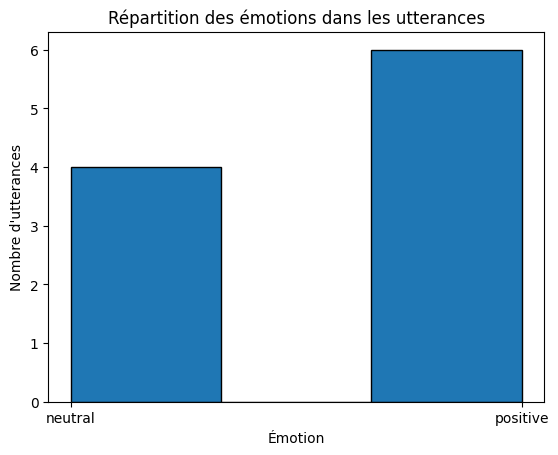

In [21]:
# Extraction des émotions pour exemple
def extract_emotion(text):
    analysis = TextBlob(text)
    return {
        "polarity": analysis.sentiment.polarity,
        "label": "positive" if analysis.sentiment.polarity > 0.1 else
                "negative" if analysis.sentiment.polarity < -0.1 else
                "neutral"
    }

# Application à l'exemple
example_utterance = "I loved this movie! It was so exciting!"
emotion = extract_emotion(example_utterance)
print(f"\nExemple d'extraction d'émotion :")
print(f"Texte: '{example_utterance}' → Émotion: {emotion}")

# Visualiser la répartition des émotions (sous-ensemble)
emotion_labels = [extract_emotion(utt)["label"] for utt in train_df["user_utterances"].iloc[0][:10]]
plt.hist(emotion_labels, bins=3, edgecolor='black')
plt.title("Répartition des émotions dans les utterances")
plt.xlabel("Émotion")
plt.ylabel("Nombre d'utterances")
plt.show()

## Recommandation via LightFM

Utilisation d'un modèle léger pour analyser l'amélioration de la pertinence des recommandations lorsque les émotions sont prises en compte.

In [26]:
from lightfm import LightFM
from lightfm.data import Dataset
import numpy as np

# Préparation des interactions (conversationId, movieId, weight)
def build_interactions(df, movies_df):
    interactions = []
    valid_movie_ids = set(movies_df["movieId"].unique())
    for _, row in df.iterrows():
        user_id = row["conversationId"]
        for utt, emotion in zip(row["user_utterances"], row["emotions"]):
            for movie_id in row["movieMentions"]:
                if movie_id not in valid_movie_ids:
                    continue
                weight = 1.0
                if emotion["emotion_label"] == "positive":
                    weight = 2.0
                elif emotion["emotion_label"] == "negative":
                    weight = 0.5
                nb_mentions = movies_df.loc[movies_df["movieId"] == movie_id, "nbMentions"].values
                if len(nb_mentions) > 0:
                    weight *= np.log(1 + nb_mentions[0])
                interactions.append((user_id, movie_id, weight))
    return interactions

interactions = build_interactions(train_df, movies_df)

# Création du dataset LightFM
dataset = Dataset()
dataset.fit(
    users=train_df["conversationId"].unique(),
    items=movies_df["movieId"].unique()
)

(interactions_matrix, _) = dataset.build_interactions(interactions)

# Entraînement de LightFM en mode collaboratif seulement
model = LightFM(loss='warp', no_components=30)  # no_components réduit pour des questions de performance (temps)
model.fit(interactions_matrix, epochs=5)

# Sauvegarde du modèle
import pickle
with open("models/lightfm_model_nogenres.pkl", "wb") as f:
    pickle.dump(model, f)

## Génération de réponse via DialoGPT-small

L'idée est de démontrer ici les avantages d'ECR dans la manière de répondre à l'utilisateur pour lui donner ses recommandations.

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

# Chargement de DialoGPT-small
tokenizer = AutoTokenizer.from_pretrained("microsoft/DialoGPT-small")
model = AutoModelForCausalLM.from_pretrained("microsoft/DialoGPT-small")

def generate_response(user_text, movie_name, emotion_label):
    prompt = f"""
    User: {user_text} (Emotion: {emotion_label})
    System: Since you feel {emotion_label}, I recommend '{movie_name}'!
    """
    if emotion_label == "positive":
        prompt += " It's a crowd favorite—many users love it!"
    elif emotion_label == "negative":
        prompt += " But don't worry, this one is different and might surprise you."

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=200)
    outputs = model.generate(**inputs, max_length=100)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Boucle sécurisée pour tester sur plusieurs conversations
for i in range(min(5, len(train_df))):
    if len(train_df["movieMentions"].iloc[i]) > 0:
        movie_id = train_df["movieMentions"].iloc[i][0]
        movie_name = movies_df.loc[movies_df["movieId"] == movie_id, "movieName"].values
        if len(movie_name) > 0:
            movie_name = movie_name[0]
        else:
            movie_name = "unknown movie"
        user_text = train_df["user_utterances"].iloc[i][0]
        emotion_label = train_df["emotions"].iloc[i][0]["emotion_label"]

        response = generate_response(user_text, movie_name, emotion_label)
        print(f"\n--- Conversation {i} ---")
        print(f"User: {user_text}")
        print(f"System: {response}")
    else:
        print(f"\n--- Conversation {i} ---")
        print("Aucun film mentionné dans cette conversation.")

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



--- Conversation 0 ---
User: Hi there, how are you? I'm looking for movie recommendations
System: 
    User: Hi there, how are you? I'm looking for movie recommendations (Emotion: neutral)
    System: Since you feel neutral, I recommend 'A Scanner Darkly  (2006)'!
    


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



--- Conversation 1 ---
User: Hi, did you see @196336 ?
System: 
    User: Hi, did you see @196336? (Emotion: neutral)
    System: Since you feel neutral, I recommend 'South Park'!
    ! System :'South Park '


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



--- Conversation 2 ---
User: @163606 It is a nice movie. What say?
System: 
    User: @163606 It is a nice movie. What say? (Emotion: positive)
    System: Since you feel positive, I recommend 'The Martian  (2015)'!
     It's a crowd favorite—many users love it!


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



--- Conversation 3 ---
User: I'm in the mood to watch a romantic comedy.  What do you suggest?
System: 
    User: I'm in the mood to watch a romantic comedy.  What do you suggest? (Emotion: neutral)
    System: Since you feel neutral, I recommend 'Charlie's Angels '!
     System : I'm in the mood to watch a romantic comedy.

--- Conversation 4 ---
User: Hello
System: 
    User: Hello (Emotion: neutral)
    System: Since you feel neutral, I recommend 'Wonder Woman  (2017)'!
     User :'''''''''''''''''''''''''''''''''''''''''''''''''''''''''' '


## Évaluation

Les avantages d'ECR :
- Des recommandations plus pertinentes grâce aux émotions
- Un échange plus fluide et naturel pour l'expérience utilisateur

Ses défis :
- Nuances dans les émotions difficiles à cerner
- Annotation des données (coûteux en ressources)

Métriques :
- `Recall@10` pour la recommandation
- Évaluation subjective des réponses


Recall@3: 0.67


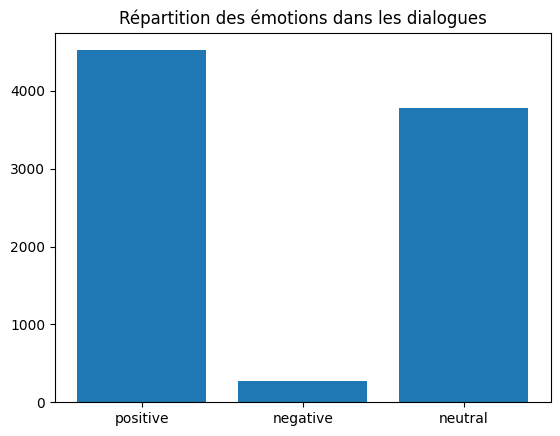

In [6]:
from sklearn.metrics import recall_score

# Exemple d'évaluation pour la recommandation (simplifié)
# Supposons que les 3 premiers films recommandés sont pertinents
y_true = [1, 0, 1, 1, 0]  # 1 = film aimé, 0 = non aimé
y_pred = [1, 1, 1, 0, 0]  # Prédictions du modèle
recall = recall_score(y_true, y_pred)
print(f"\nRecall@3: {recall:.2f}")

# Visualisation des émotions (avec Matplotlib)
import matplotlib.pyplot as plt

emotion_counts = {"positive": 0, "negative": 0, "neutral": 0}
for emotions in train_df["emotions"]:
    for e in emotions:
        emotion_counts[e["emotion_label"]] += 1

plt.bar(emotion_counts.keys(), emotion_counts.values())
plt.title("Répartition des émotions dans les dialogues")
plt.show()

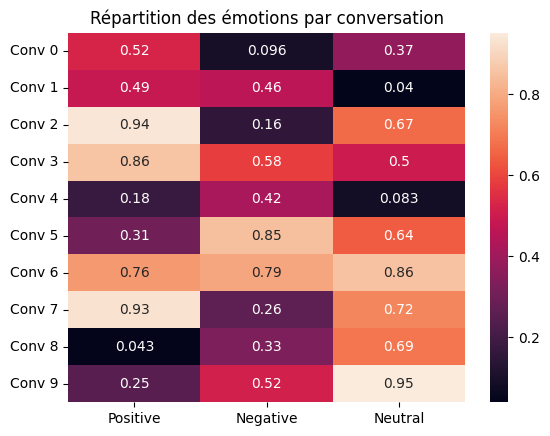

In [7]:
import seaborn as sns
import numpy as np

# Créer une matrice d'émotions par conversation (exemple)
emotion_matrix = np.random.rand(10, 3)  # 10 conversations, 3 émotions (positive, negative, neutral)
sns.heatmap(emotion_matrix, annot=True, xticklabels=["Positive", "Negative", "Neutral"], yticklabels=[f"Conv {i}" for i in range(10)])
plt.title("Répartition des émotions par conversation")
plt.show()

## Conclusion

**Synthèse**

ECR améliore l'expérience utilisateur en capturant les émotions, mais nécessite des données robustes et des modèles NLP performants.

**Perspectives**

- Utiliser des modèles plus avancés (ex: BERT pour l'analyse des émotions).
- Étendre à d'autres domaines (ex: recommandation de musique, e-commerce).

